# Homework 2

### Deadline: Tuesday 20 May 2025 (by 19h00)

### Credits: 20 points


## Instructions:

- The homework is **individual**. Please include your name in the notebook.

- **Please send your compressed tar file with the following tree scheme:**

```
homework2.tar
    
    pdediffusion
    ├── metalconduction.ipynb
    ├── metalconduction.py     
    └── outputfolder
```

## Name: Males-Araujo Yorlan

## 1. Thermodynamics and Heat Conduction (12 points)

Please include your solutions to this problem within a single python notebook file: **metalconduction.ipynb**

Use appropriate numerical algorithms to study how the temperature profile in a heated metal wire evolves in time, under different initial and boundary conditions. For this, you need to numerically solve the 1D heat equation:

$$\frac{\partial T}{\partial t}=\alpha\frac{\partial^2 T}{\partial x^2}$$

where $T=T(x, t)$ describes the temperature of the metal, $x$ is position, $t$ is time, and $\alpha$ is the thermal diffusivity of the metal. We will consider the following metals:

| Metal      | $\alpha$ $\left(\frac{\text{mm}^2}{\text{s}}\right)$ |
|------------|--------------------------|
| Copper     | 111                      |
| Iron       | 23                       |
| Aluminum   | 97                       |
| Brass      | 34                       |
| Steel      | 18                       |
| Zinc       | 63                       |
| Lead       | 22                       |
| Titanium   | 9.8                      |

Assume that the metal wire has a length of $20\,\rm cm$, and choose the wire midpoint as the origin for the domain.

### Code design:

Organise your code using **python classes** and carry out the following tasks:

##### **(a)** Place the metals and diffusivities in a python dictionary.
---
We transformed from $\rm mm^2/s$ to $\rm cm^2/s$ for convenience.

---

##### **(bx2)** Create a simulation initialisation routine where e.g. the mesh, the initial conditions, and the boundary conditions are all set up.

Consider two types of **initial conditions**:

- **Smooth**, which sets the initial temperature profile in degrees Celsius to be:

$$T(x, 0)= 175 - 50\cos\left(\frac{\pi x}{5}\right) - x^2$$

where $x$ is in units of $\rm cm$. 

- **Noisy**, which adds some noise $f(x)$ with amplitude $\beta$ to the initial condition:

$$T(x, 0)= 175 - 50\cos\left(\frac{\pi x}{5}\right) - x^2 + \beta\,f(x)\,g(x)$$

Note that you need to find an appropriate apodisation function $g(x)$ so that the initial boundary conditions remain fixed at $25\,\rm C$. Similarly, a default amplitude for the noise function can be set to be less than a hundredth of the peak temperature value. 

Also, consider two types of **boundary conditions**:

- **Fixed**, which keep the temperatures at the edges of the metal wire fixed at a temperature of $25\,\rm C$. 
    
- **Varying**, which assume that the boundaries cannot be kept constant (because of e.g. a faulty cooling system). Instead they also evolve in time according to the following functions:

    $T(+10\,{\rm cm}, t) = 25 + 0.12\,t$

    $T(-10\,{\rm cm}, t) = 25 + 0.27\,t$

##### **(cx3)** Construct a Crank-Nicolson algorithm to simulate **the evolution of an initial temperature profile** and find the **time in seconds at which thermal equilibrium is reached** in an input metal wire (from the dictionary). **Hint:** You need to define some criteria to determine thermal equilibrium.

---
Both (b) and (c) were implemented in a single class called `SingleSolver`.

---

### Smooth-Fixed Simulations:

##### **(d)** Pick **two metal wires** from the dictionary and run both simulations using your Crank-Nicolson algorithm. To compare the results, make a high-quality, 2-column figure showing the time evolution of the 1D temperature profile, $T=T(x, t)$, of each metal wire versus $x$ at a few selected times.

We chose Copper and Titanium because they have the highest and lowest diffusivity, respectively.

In [1]:
# My code
from metalconduction import SingleSolver

# Libraries
import re
import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
# Objects
copper = SingleSolver(metal = 'Copper')
titanm = SingleSolver(metal = 'Titanium')

In [3]:
# Parameters
dt      = 0.2
dx      = 0.05
t_max   = 700.0

In [4]:
# Integrate
x_copper, t_copper, T_copper, eq_cop, eq_cop_time = copper.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Smooth",
    bc_type = "Fixed"
)

x_titanm, t_titanm, T_titanm, eq_tit, eq_tit_time = titanm.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Smooth",
    bc_type = "Fixed"
)

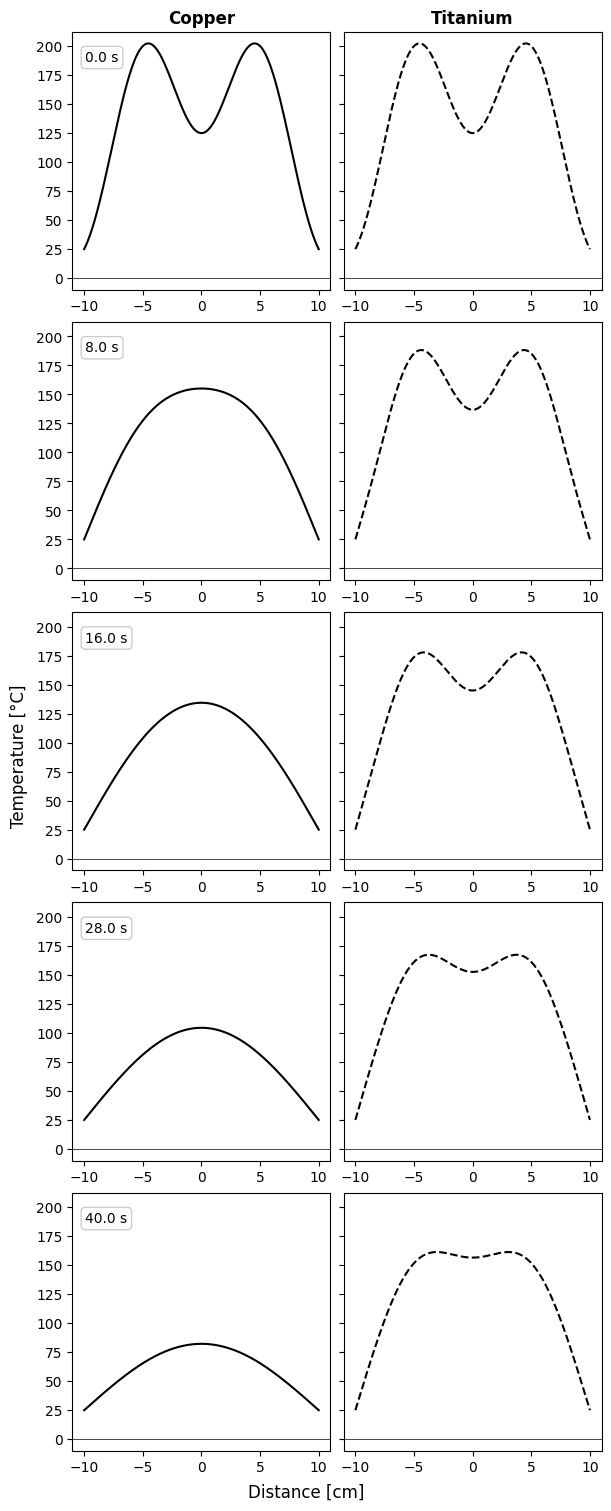

In [5]:
# Plot
fig, axs = plt.subplots(5, 2, figsize=(6, 15), sharey = True, constrained_layout = True)

# Labels
fig.supxlabel('Distance [cm]', fontsize = 12)
fig.supylabel('Temperature [°C]', fontsize = 12)

# Metals
axs[0, 0].set_title('Copper', fontweight = 'bold', fontsize = 12)
axs[0, 1].set_title('Titanium', fontweight = 'bold', fontsize = 12)
 
# Snapshots
time_indices = [0, 40, 80, 140, 200]

# Loop
for i, idx in enumerate(time_indices):

    # Solutions
    axs[i, 0].plot(x_copper, T_copper[:, idx], color = "k")
    axs[i, 1].plot(x_titanm, T_titanm[:, idx], ls ='--', color = "k")

    axs[i, 0].axhline(0, color = "k", lw = 0.5)
    axs[i, 1].axhline(0, color = "k", lw = 0.5)
    
    # Time (just one because they're the same)
    axs[i, 0].text(0.05, 0.9, f'{t_copper[idx]:.1f} s', 
                   transform = axs[i, 0].transAxes, fontsize = 10,
                   va = 'center', bbox = dict(facecolor = 'w', alpha = 0.2, boxstyle='round'))
    
    axs[i, 1].tick_params(labelleft=False)

plt.show()

In [6]:
# Thermal equilibrium
print("--" * 20)
print("THERMAL EQUILIBRIUM")
print("--" * 20)
if all([eq_cop, eq_tit]):
    print("Reached in all metals!")
    print(f"Copper: {eq_cop_time:.2f} s")
    print(f"Titanium: {eq_tit_time:.2f} s")
else:
    print("Not reached in all metals.")
print("--" * 20)

----------------------------------------
THERMAL EQUILIBRIUM
----------------------------------------
Reached in all metals!
Copper: 149.40 s
Titanium: 686.40 s
----------------------------------------


As expected, Copper decreases its temperature faster than Titanium because it has a higher diffusivity.

### Smooth-Fixed versus Noisy-Fixed Simulations:

##### **(e)** Study heat diffusion only in the Zinc wire considering **smooth versus noisy initial conditions** with noise of 3 different amplitudes. To compare the results, make a high-quality, 4-panel figure (with 2 columns and 2 rows) showing the time evolution of the 1D temperature profile, $T=T(x, t)$, of the Zinc metal wire versus $x$ at a few selected times, under different initial conditions (smooth vs. 3 noisy cases).

In [7]:
# Zinc object
zinc = SingleSolver(metal = 'Zinc')

In [8]:
# Smooth
x_smooth, t_smooth, T_smooth, eq_smooth, eq_smooth_time = zinc.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Smooth",
    bc_type = "Fixed"
)

In [9]:
# Noises
large_noise  = 0.1
medium_noise = 0.05
small_noise  = 0.01

# Large noise
x_large, t_large, T_large, eq_large, eq_large_time = zinc.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Noisy",
    bc_type = "Fixed",
    noise_factor = large_noise
)

# Medium noise
x_medium, t_medium, T_medium, eq_medium, eq_medium_time = zinc.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Noisy",
    bc_type = "Fixed",
    noise_factor = medium_noise
)

# Small noise
x_small, t_small, T_small, eq_small, eq_small_time = zinc.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Noisy",
    bc_type = "Fixed",
    noise_factor = small_noise
)

In [10]:
# Indices
indices = [0, 20, 50, 100, 150, 200, 400, 800, 1000, 1500, 2000, 3000]

# Colors
n_plots = len(indices)
R = np.linspace(1, 0, n_plots)
G = 0
B = np.linspace(0, 1, n_plots)

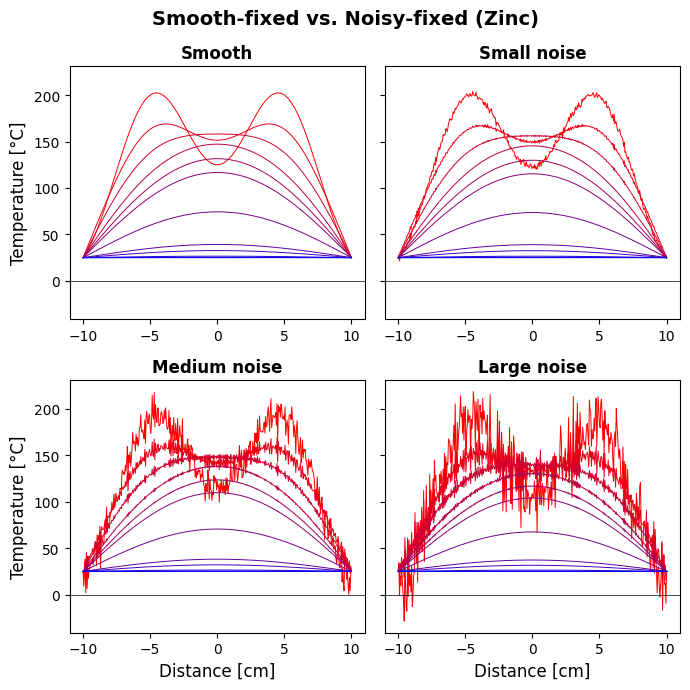

In [11]:
# Plot
fig, axs = plt.subplots(2, 2, figsize=(7, 7), sharey = True)

# Title
fig.suptitle('Smooth-fixed vs. Noisy-fixed (Zinc)', fontweight = 'bold', fontsize = 14)

# Loop
for i, idx in enumerate(indices):

    # Color
    color = [R[i], G, B[i]]

    # All plots
    axs[0, 0].plot(x_smooth, T_smooth[:, idx], color = color, lw = 0.7)
    axs[0, 1].plot(x_small, T_small[:, idx], color = color, lw = 0.7)
    axs[1, 0].plot(x_medium, T_medium[:, idx], color = color, lw = 0.7)
    axs[1, 1].plot(x_large, T_large[:, idx], color = color, lw = 0.7)

# 0-lines
axs[0, 0].axhline(0, color = "k", lw = 0.5)
axs[0, 1].axhline(0, color = "k", lw = 0.5)
axs[1, 0].axhline(0, color = "k", lw = 0.5)
axs[1, 1].axhline(0, color = "k", lw = 0.5)

# Titles and labels
axs[0, 0].set_title('Smooth', fontweight = 'bold', fontsize = 12)
axs[0, 1].set_title('Small noise', fontweight = 'bold', fontsize = 12)
axs[1, 0].set_title('Medium noise', fontweight = 'bold', fontsize = 12)
axs[1, 1].set_title('Large noise', fontweight = 'bold', fontsize = 12)

axs[0, 0].set_ylabel('Temperature [°C]', fontsize = 12)
axs[1, 0].set_ylabel('Temperature [°C]', fontsize = 12)
axs[1, 0].set_xlabel('Distance [cm]', fontsize = 12)
axs[1, 1].set_xlabel('Distance [cm]', fontsize = 12)

plt.tight_layout()
plt.show()

In [12]:
# Thermal equilibrium check
print("--" * 20)
print("THERMAL EQUILIBRIUM")
print("--" * 20)
if all([eq_smooth, eq_large, eq_medium, eq_small]):
    print("Reached in all cases!")
    print(f"Smooth: {eq_smooth_time:.2f} s")
    print(f"Large noise: {eq_large_time:.2f} s")
    print(f"Medium noise: {eq_medium_time:.2f} s")
    print(f"Small noise: {eq_small_time:.2f} s")
else:
    print("Not reached in all cases.")
print("--" * 20)

----------------------------------------
THERMAL EQUILIBRIUM
----------------------------------------
Reached in all cases!
Smooth: 226.60 s
Large noise: 217.00 s
Medium noise: 221.60 s
Small noise: 225.60 s
----------------------------------------


All the noise is eventually smoothed out, resulting in similar temperature profiles and thermal equilibrium being reached at nearly the same time.

### Smooth-Fixed versus Smooth-Varying Simulations:

##### **(f)** Study heat diffusion only in the Aluminum wire considering **fixed versus varying boundary conditions**. To compare the results, make a high-quality, 2-column figure showing the time evolution of the 1D temperature profile, $T=T(x, t)$, of the Aluminum metal wire versus $x$ at a few selected times, under different boundary conditions.

In [13]:
# Object
alum = SingleSolver(metal = 'Aluminum')

In [14]:
# Integrate
x_fixed, t_fixed, T_fixed, eq_fixed, eq_fixed_time = alum.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Smooth",
    bc_type = "Fixed"
)

x_varying, t_varying, T_varying, eq_varying, eq_varying_time = alum.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Smooth",
    bc_type = "Varying"
)

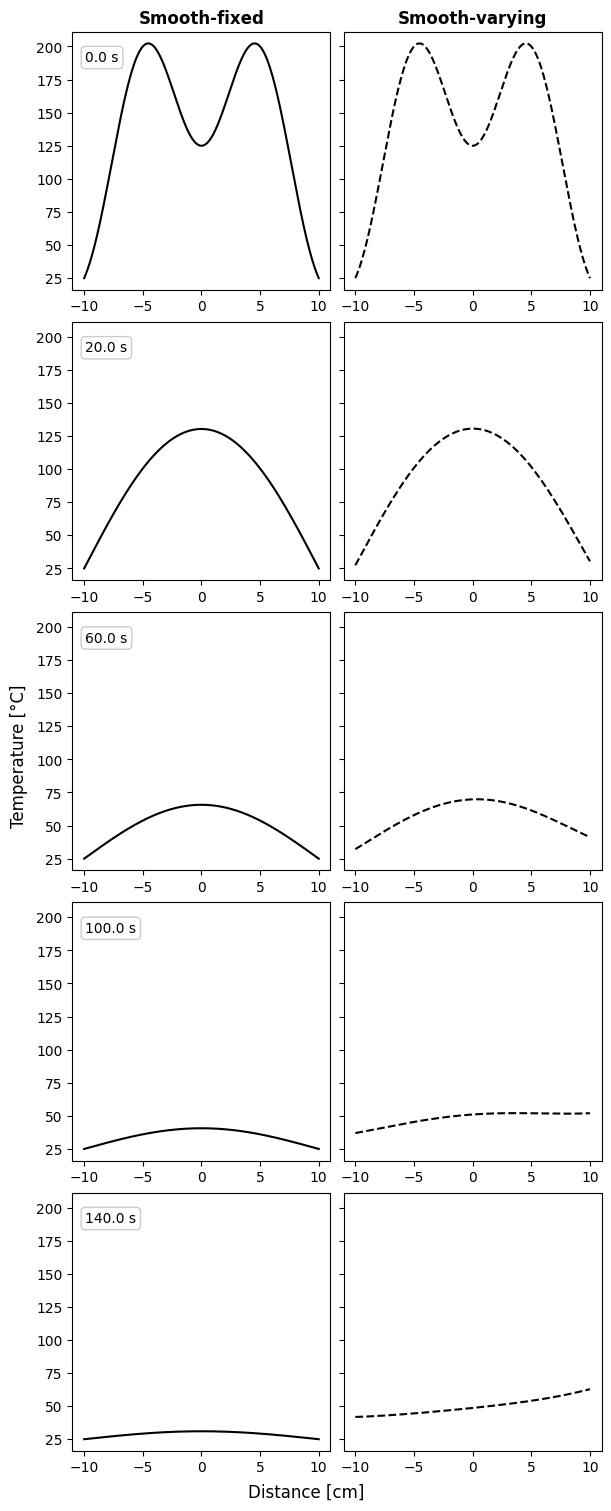

In [15]:
# Plot
fig, axs = plt.subplots(5, 2, figsize=(6, 15), sharey = True, constrained_layout = True)

# Labels
fig.supxlabel('Distance [cm]', fontsize = 12)
fig.supylabel('Temperature [°C]', fontsize = 12)

# Titles
axs[0, 0].set_title('Smooth-fixed', fontweight = 'bold', fontsize = 12)
axs[0, 1].set_title('Smooth-varying', fontweight = 'bold', fontsize = 12)
 
# Snapshots
time_indices = [0, 100, 300, 500, 700]

# Loop over time
for i, idx in enumerate(time_indices):

    # Solutions
    axs[i, 0].plot(x_fixed, T_fixed[:, idx], color = "k")
    axs[i, 1].plot(x_varying, T_varying[:, idx], ls ='--', color = "k")
    
    # Time
    axs[i, 0].text(0.05, 0.9, f'{t_fixed[idx]:.1f} s', 
                   transform = axs[i, 0].transAxes, fontsize = 10,
                   va = 'center', bbox = dict(facecolor = 'w', alpha = 0.2, boxstyle='round'))
    
    axs[i, 1].tick_params(labelleft=False)

plt.show()

In [16]:
# Thermal equilibrium
print("--" * 20)
print("THERMAL EQUILIBRIUM")
print("--" * 20)
if all([eq_fixed, eq_varying]):
    print("Reached in all cases!")
    print(f"Fixed: {eq_fixed_time:.2f} s")
    print(f"Varying: {eq_varying_time:.2f} s")
else:
    print("Not reached in all cases.")
print("--" * 20)

----------------------------------------
THERMAL EQUILIBRIUM
----------------------------------------
Reached in all cases!
Fixed: 165.40 s
Varying: 101.40 s
----------------------------------------


I was not expecting the varying boundary conditions to reach thermal equilibrium because they're defined to change with each time step. I assume it's because the temperature change was so small that my condition for thermal equilibrium was still met. **A better criteria for thermal equilibrium would have identified such changes and not considered them as thermal equilibrium.** Note to myself.

### Analysis:

##### **(g)** Can we use explicit or FFT methods to solve this problem? Explain.

We could have used explicit methods, but they've been shown to have a very small range of stability when compared to implicit methods. If we want to have accurate solutions, then no, we cannot use explicit methods. Nor can we use FFT methods because they make boundaries oscillate, which would have introduced errors in our simulations. We could have used an extended domain in order to diminish such oscillations, but it would still come with (smaller) errors.

##### **(h)** Does the input noise amplitude change the time at which thermal equilibrium is reached or not? Why?

Not significantly. It does change it a little but, as mentioned above, the noise is smoothed out over time, and the system converges to thermal equilibrium in roughly the same time.

##### **(i)** What is the effect of a faulty cooling system on the temperature profile?

Opposite to what the numerics suggest, I think that a faulty cooling system wouldn't allow the system to reach thermal equilibrium. In our case, the temperature profile increases because the boundary conditions are defined to increase with time. The effect changes the profile's shape after most diffusion has occurred.

## 2. Joblib Parallelisation (8 points)

Consider the same statement provided in problem 1. All code should be organised in **python classes**.

### Parallelisation with joblib:

**(a)** Imagine we wish to run several simulations in parallel for the metals included in the dictionary. Within the **metalconduction.ipynb** notebook, create a routine that uses ```joblib``` to parallelise the simulation executions in $n$ CPUs.

---
Done. Multiple simulations can be run in serial or parallel with the class `MultipleSolver`. 

---

**(b)** Test your implementation by running $2$ simulations ($1$ for Iron and $1$ for Lead) first in serial and then in parallel (simultaneously). For the serial run, $n=1$ CPU core. For the parallel run, $n=2$ CPU cores. The time should go down. **Hint:** You need to add time stamps to quantify and return log files with the execution times. 

In [17]:
# Our new class
from metalconduction import MultipleSolver

In [18]:
# Metals (we added two metals in order to test with 4 cores too)
metals = ['Iron', 'Lead', 'Copper', 'Brass']

# Objects
paral4 = MultipleSolver(
    metals = metals,
    parallel = True,
    n_jobs = 4
)
paral2 = MultipleSolver(
    metals = metals,
    parallel = True,
    n_jobs = 2
)
serial = MultipleSolver(
    metals = metals,
    parallel = False
)

In [19]:
# Integrate
print("**" * 30)

# New params
dx    = 0.02
t_max = 100  # Not going for thermal equilibrium

results_paral4, time_paral4 = paral4.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Smooth",
    bc_type = "Fixed"
)

print("**" * 30)

results_paral2, time_paral2 = paral2.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Smooth",
    bc_type = "Fixed"
)

print("**" * 30)

results_serial, time_serial = serial.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Smooth",
    bc_type = "Fixed"
)

print("**" * 30)

************************************************************
> Metals to be integrated:
  - Iron [0.23 cm²/s]
  - Lead [0.22 cm²/s]
  - Copper [1.11 cm²/s]
  - Brass [0.34 cm²/s]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                PARALLEL INTEGRATION STARTED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
> Number of jobs: 4.

> Reached thermal equilibrium:
  - Iron: False, 100.00 s
  - Lead: False, 100.00 s
  - Copper: False, 100.00 s
  - Brass: False, 100.00 s

> Total integration time: 39.96 s.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                PARALLEL INTEGRATION ENDED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
************************************************************
> Metals to be integrated:
  - Iron [0.23 cm²/s]
  - Lead [0.22 cm²/s]
  - Copper [1.11 cm²/s]
  - Brass [0.34 cm²/s]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                PARALLEL INTEGRATION STARTED
━━━━━━━━

**(c)** Make a scaling plot showing (serial and parallel) execution times in the $Y$ axis versus the number of CPU cores ($n$) in the $X$ axis.

In [20]:
# CPUs array
cpus = np.array([1, 2, 4])

# Times
times = np.array([time_serial, time_paral2, time_paral4])

# Ideal time
ideal_time = time_serial / cpus

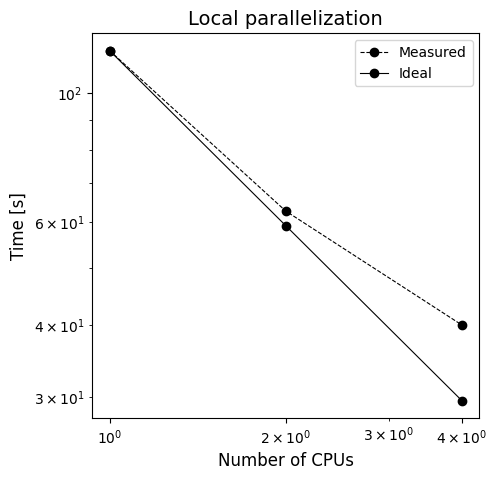

In [21]:
# Plot
plt.subplots(figsize=(5, 5))

plt.plot(cpus, times, marker = 'o', color = 'k', ls = '--', label = 'Measured', lw = 0.8)
plt.plot(cpus, ideal_time, marker = 'o', color = 'k', label = 'Ideal', lw = 0.8)

plt.loglog()

plt.xlabel('Number of CPUs', fontsize = 12)
plt.ylabel('Time [s]', fontsize = 12)
plt.title('Local parallelization', fontsize = 14)

plt.xticks(cpus)
plt.legend()

plt.show()

True scaling is not achieved, but I wouldn't say it's bad either.

### HPC execution:

**(d)** Convert your notebook code into a script called: **metalconduction.py**. Then, copy it to the CEDIA cluster (or the Imbabura cluster), reserve computing resources (e.g. $8$ CPU cores), then run your code in serial and parallel for all the $8$ metals at increasing $n$ (e.g. $1$, $2$, $4$, $8$ CPU cores). Export log files from each run, so that the thermal equilibrium times and simulation run times can be analysed later. Include the log files and all your SLURM job scripts in the **outputfolder.**

---
I decided to write all the code in such file from the beginning, so I didn't need to convert it. 

---

**(e)** Within the **metalconduction.ipynb** notebook, create a routine to open the log files produced by the serial run and all the different parallel runs on the HPC cluster.

We ran the same simulation with different numbers of CPU cores $5$ times, and the results were consistent.  

We'll show the structure of the log files, and then get the information we need.

In [22]:
# We choose one log file 
log_file = "outputfolder/run_0/azula.2.par.log"

# Open
with open(log_file, 'r') as file:
    lines = file.readlines()

# Print
for line in lines:
    print(line.strip())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
|                      '||
|||    ......  ... ...   ||   ....
|  ||   '  .|'   ||  ||   ||  '' .||
.''''|.   .|'     ||  ||   ||  .|' ||
.|.  .||. ||....|  '|..'|. .||. '|..'|'.v1.0
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
METAL CONDUCTION SIMULATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
> Running on: dgx-node-0-0.cedia.edu.ec

> Parameters:
- dt          0.200 s
- dx          0.100 cm
- x_min      -10.00 cm
- x_max       10.00 cm
- t_max       700.00 s
- ic_type     Smooth
- bc_type     Fixed

> Metals to be integrated:
- Copper [1.11 cm²/s]
- Iron [0.23 cm²/s]
- Aluminum [0.97 cm²/s]
- Brass [0.34 cm²/s]
- Steel [0.18 cm²/s]
- Zinc [0.63 cm²/s]
- Lead [0.22 cm²/s]
- Titanium [0.098 cm²/s]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PARALLEL INTEGRATION STARTED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
> Number of jobs: 2.

> Reached thermal equil

In [23]:
# Empty list
data = []

# Define the matching pattern
pattern = "outputfolder/run_*/azula.*.log"
    
# Find all log files
for log_file in glob.glob(pattern):

    # Run number
    run_id = int(log_file.split('/')[1].split('_')[1])
    
    # Core number
    n_jobs = int(log_file.split('/')[-1].split('.')[1])
    
    # Execution time
    with open(log_file, 'r') as f:
        content = f.read()

        # Use an operator to assign the value
        if match := re.search(r"> Total integration time: (\d+\.\d+)", content):
            time = float(match.group(1))

            # Append them all
            data.append([run_id, n_jobs, time])

In [24]:
# Create dataframe
df = pd.DataFrame(data, columns=['Run', 'Cores', 'Execution time'])

# See it
df

,Run,Cores,Execution time
0,2,8,2.81
1,2,4,4.50
2,2,2,8.58
3,2,1,16.06
4,3,8,2.82
5,3,4,4.56
6,3,2,8.38
7,3,1,15.37
8,1,8,2.91
9,1,4,5.54


**(f)** Make a new scaling plot for the HPC cluster showing the executions times on the Y-axis and number of cores on the X-axis. Display also the **Amdahl's law**. 

We'll take the average of the each of the $5$ runs.

In [25]:
# Time averages and standard deviations
time_avg = df.groupby('Cores')['Execution time'].mean().reset_index()
time_std = df.groupby('Cores')['Execution time'].std().reset_index()

# Arrays
avgs   = np.array(time_avg['Execution time'])
stds   = np.array(time_std['Execution time'])
cores  = np.array(time_avg['Cores'])

In [26]:
# Ideal time
ideal_time = avgs[0] / cores

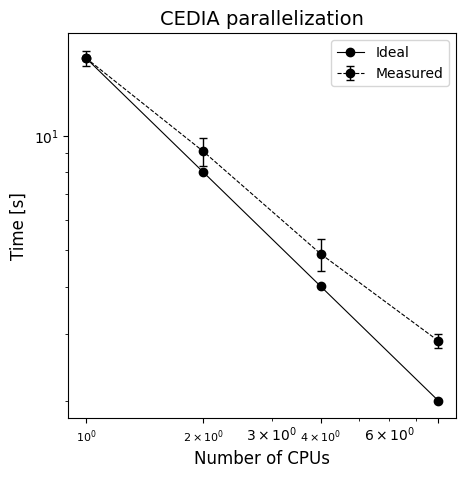

In [27]:
# Plot
plt.subplots(figsize=(5, 5))

plt.title('CEDIA parallelization', fontsize = 14)

plt.plot(cores, ideal_time, marker = 'o',
         color = 'k', label='Ideal', lw = 0.8)
plt.errorbar(cores, avgs, yerr = stds, fmt = '--o', lw = 0.8,
             color = 'k', label='Measured',
             capsize = 3, elinewidth = 1, capthick = 1)

plt.loglog()

plt.xlabel('Number of CPUs', fontsize = 12)
plt.ylabel('Time [s]', fontsize = 12)
plt.xticks(cores, fontsize = 8)
plt.legend()
plt.show()

### Analysis:

**(g)** Compare the Amdahl's law to your results and comment on the findings (e.g. does your parallelisation follow Amdahl's law? Why yes or no?)



The comparison is done above.

The tendency of our results is close to that of Amdahl's law, but, of course, it doesn't reach the ideal case. This might be due to communication overhead. It's true that problem is not big, but we decided to keep it like that because we were getting acceptable results.

**(h)** Make a plot showing the thermal equilibrium times versus diffusivities. Do the different thermal equilibrium times for distinct metals influence how ```joblib``` handles parallelisation?


We'll manually extract the data from the log file shown above. We're aware there are better ways to do this.

In [28]:
# Info per metal, [cm²/s, s]
copper   = [1.110, 149.4]
iron     = [0.230, 442.4]
aluminum = [0.970, 165.2]
brass    = [0.340, 346.0]
steel    = [0.180, 510.2]
zinc     = [0.630, 226.4]
lead     = [0.220, 454.0]
titanium = [0.098, 685.4]

# All (from lower to higher diffusivity)
metals = [titanium, steel, lead, iron, brass, zinc, aluminum, copper]

In [29]:
# Diffusion coefficients
diffusivities = [d[0] for d in metals]

# Thermal eq. times
thermal_eq_ts = [th[1] for th in metals]

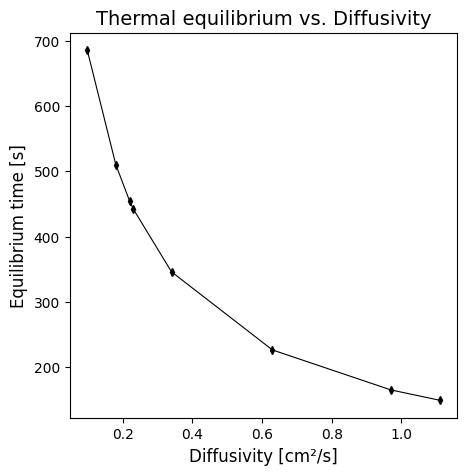

In [30]:
# Plot
plt.figure(figsize=(5, 5))

plt.title('Thermal equilibrium vs. Diffusivity', fontsize = 14)

plt.plot(diffusivities, thermal_eq_ts, marker = 'd', color = 'k',
         lw = 0.8, markersize = 4)

plt.xlabel('Diffusivity [cm²/s]', fontsize = 12)
plt.ylabel('Equilibrium time [s]', fontsize = 12)
plt.show()

We observe the higher the diffusivity, the faster the thermal equilibrium is reached in all cases. This is expected.

About the influence of diffussivity on parallelisation, I don't think it affects it because I didn't include any stop conditions on my code when reaching thermal equilibrium. **Instead, all processes run until reaching the maximum time given by the user, which is the same for all metals.** However, if implemented, I think it would indeed affect the parallelisation since such time is different for each metal, resulting in some cores finishing before others.

---
Thank you for designing this homework, prof. Wladimir. I learned a lot from it and it was fun to do!

---